Cells: 1152, Observations: 150, λ=0.5
RMSE to noisy data: 0.208 mGal
Misfit to clean data: 0.200 mGal


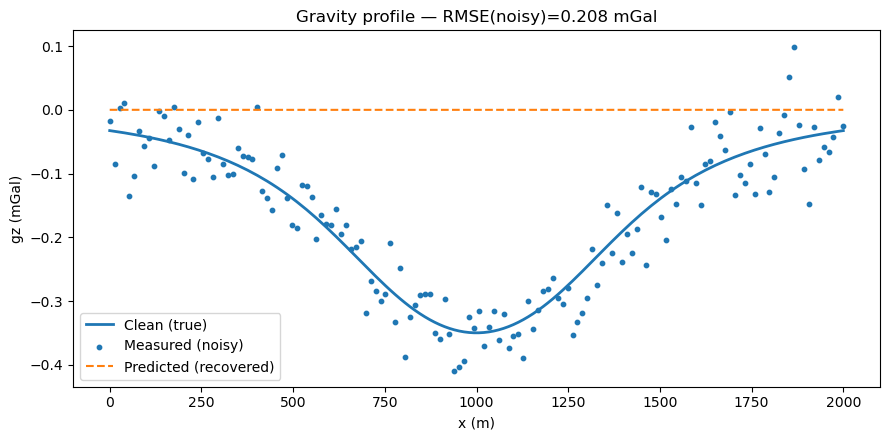

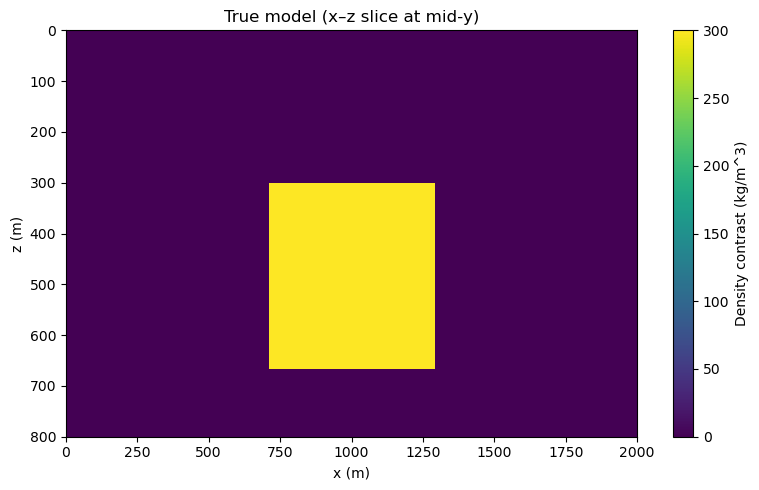

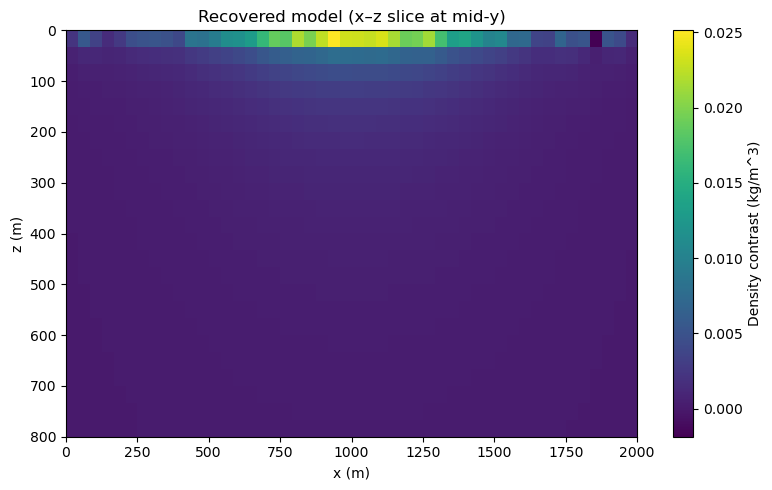

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import solve

# ---------- Constants & units ----------
G_CONST = 6.67430e-11     # m^3 kg^-1 s^-2
M_PER_S2_TO_MGAL = 1e5    # 1 m/s^2 = 1e5 mGal

# ---------- Survey & model knobs ----------
# Model box (meters)
Lx, Ly, Lz = 2000.0, 200.0, 800.0   # x-range, y-range, depth

# Discretization (keep modest for fast inversion)
nx, ny, nz = 48, 1, 24

# Surface observation line
n_obs = 150

# Noise (mGal)
noise_std_mgal = 0.05

# Tikhonov lambda
lam = 0.5

# ---------- Derived grid ----------
dx, dy, dz = Lx/nx, Ly/max(ny,1), Lz/nz
x_edges = np.linspace(0, Lx, nx+1)
y_edges = np.linspace(0, Ly, ny+1)
z_edges = np.linspace(0, Lz, nz+1)   # z positive downward

xc = 0.5*(x_edges[:-1] + x_edges[1:])
yc = 0.5*(y_edges[:-1] + y_edges[1:])
zc = 0.5*(z_edges[:-1] + z_edges[1:])

# Observation geometry: profile along x at surface (z=0), mid-y
x_obs = np.linspace(0.0, Lx, n_obs)
y_obs = np.full_like(x_obs, Ly/2)
z_obs = np.zeros_like(x_obs)

# ---------- True density contrast model (kg/m^3) ----------
rho_true = np.zeros((nx, ny, nz))

# A rectangular body: tweak these to taste
x1, x2 = 700.0, 1300.0
y1, y2 = 0.0, Ly
z1, z2 = 300.0, 650.0
rho_anom = 300.0   # density contrast in kg/m^3

ix = np.where((xc >= x1) & (xc <= x2))[0]
iy = np.where((yc >= y1) & (yc <= y2))[0]
iz = np.where((zc >= z1) & (zc <= z2))[0]
for i in ix:
    for j in iy:
        for k in iz:
            rho_true[i, j, k] = rho_anom

# ---------- Forward model (point-mass approximation per voxel) ----------
Vcell = dx*dy*dz
Xc, Yc, Zc = np.meshgrid(xc, yc, zc, indexing='ij')
Xm = Xc.ravel(); Ym = Yc.ravel(); Zm = Zc.ravel()

def forward_gz(rho, xo, yo, zo):
    """Downward-positive gz at observation points (m/s^2)."""
    gz = np.zeros_like(xo, dtype=float)
    mass = rho.ravel() * Vcell
    for p in range(xo.size):
        rx = xo[p] - Xm
        ry = yo[p] - Ym
        rz = zo[p] - Zm    # zo=0 at surface; Zm>0 -> rz negative
        r3 = (rx*rx + ry*ry + rz*rz)**1.5 + 1e-30
        gz[p] = G_CONST * np.sum(mass * rz / r3)
    return gz

gz_clean_mps2 = forward_gz(rho_true, x_obs, y_obs, z_obs)
gz_clean_mgal = gz_clean_mps2 * M_PER_S2_TO_MGAL

# ---------- Add noise ----------
rng = np.random.default_rng(42)
gz_noisy_mgal = gz_clean_mgal + rng.normal(0.0, noise_std_mgal, size=n_obs)

# ---------- Build sensitivity matrix G (mGal per kg/m^3) ----------
def build_G(xo, yo, zo):
    G = np.zeros((xo.size, nx*ny*nz))
    for i in range(xo.size):
        rx = xo[i] - Xm
        ry = yo[i] - Ym
        rz = zo[i] - Zm
        r3 = (rx*rx + ry*ry + rz*rz)**1.5 + 1e-30
        # per-cell derivative: d(gz)/d(rho) = G * V * rz / r^3
        G[i, :] = G_CONST * Vcell * (rz / r3) * M_PER_S2_TO_MGAL
    return G

G = build_G(x_obs, y_obs, z_obs)

# Sanity: forward via matrix matches clean data
assert np.allclose(G @ rho_true.ravel(), gz_clean_mgal, atol=1e-6)

# ---------- Tikhonov inversion ----------
GtG = G.T @ G
rhs = G.T @ gz_noisy_mgal
m_rec = solve(GtG + (lam**2)*np.eye(G.shape[1]), rhs)
rho_rec = m_rec.reshape((nx, ny, nz))

# ---------- Predictions & metrics ----------
pred_mgal = G @ m_rec
rmse_noisy = np.sqrt(np.mean((pred_mgal - gz_noisy_mgal)**2))
misfit_clean = np.sqrt(np.mean((pred_mgal - gz_clean_mgal)**2))

print(f"Cells: {nx*ny*nz}, Observations: {n_obs}, λ={lam}")
print(f"RMSE to noisy data: {rmse_noisy:.3f} mGal")
print(f"Misfit to clean data: {misfit_clean:.3f} mGal")

# ---------- Plots ----------
plt.figure(figsize=(9,4.5))
plt.plot(x_obs, gz_clean_mgal, label="Clean (true)", linewidth=2)
plt.scatter(x_obs, gz_noisy_mgal, s=10, label="Measured (noisy)")
plt.plot(x_obs, pred_mgal, linestyle="--", label="Predicted (recovered)")
plt.xlabel("x (m)"); plt.ylabel("gz (mGal)")
plt.title(f"Gravity profile — RMSE(noisy)={rmse_noisy:.3f} mGal")
plt.legend()
plt.tight_layout()
plt.show()

extent=[0, Lx, Lz, 0]  # x left->right, z top at 0
plt.figure(figsize=(8,5))
plt.imshow(rho_true[:,0,:].T, extent=extent, aspect="auto")
plt.colorbar(label="Density contrast (kg/m^3)")
plt.xlabel("x (m)"); plt.ylabel("z (m)")
plt.title("True model (x–z slice at mid-y)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.imshow(rho_rec[:,0,:].T, extent=extent, aspect="auto")
plt.colorbar(label="Density contrast (kg/m^3)")
plt.xlabel("x (m)"); plt.ylabel("z (m)")
plt.title("Recovered model (x–z slice at mid-y)")
plt.tight_layout()
plt.show()


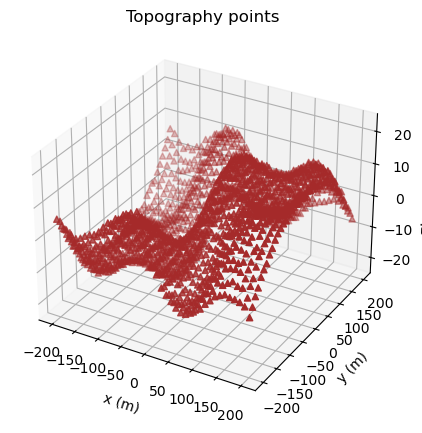

In [1]:
import numpy as np

def synthetic_topography(
    x_min=-200, x_max=200,
    y_min=-200, y_max=200,
    dx=10, dy=10,
    base_level=0.0,
    fbm_amp=20.0,
    seed=0,
    noise_sigma=0.5,
    scatter_fraction=0.0,
):
    """
    Return (N,3) array of x,y,z points representing synthetic topography.

    Parameters
    ----------
    x_min, x_max, y_min, y_max : float
        Domain bounds.
    dx, dy : float
        Sampling grid spacing.
    base_level : float
        Base elevation (meters).
    fbm_amp : float
        Relief amplitude (meters).
    seed : int
        RNG seed.
    noise_sigma : float
        Std deviation of Gaussian noise on z.
    scatter_fraction : float
        Fraction of points randomly dropped (0–1).

    Returns
    -------
    xyz : ndarray, shape (N,3)
        Point cloud of synthetic topography.
    """
    rng = np.random.default_rng(seed)

    xs = np.arange(x_min, x_max + 1e-9, dx)
    ys = np.arange(y_min, y_max + 1e-9, dy)
    X, Y = np.meshgrid(xs, ys, indexing="xy")

    # synthetic hills from sinusoids
    Z = base_level + fbm_amp * (
        np.sin(0.01*X + seed) * np.cos(0.01*Y + seed/2)
        + 0.5*np.sin(0.03*X) * np.cos(0.02*Y)
    )

    # add noise
    Z += rng.normal(0.0, noise_sigma, size=Z.shape)

    # flatten
    XX, YY, ZZ = X.ravel(), Y.ravel(), Z.ravel()

    # optional subsample to simulate scattered points
    if scatter_fraction > 0:
        keep = rng.random(XX.size) > scatter_fraction
        XX, YY, ZZ = XX[keep], YY[keep], ZZ[keep]

    return np.c_[XX, YY, ZZ]

# Example
topo = synthetic_topography()

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(topo[:,0], topo[:,1], topo[:,2], c='brown', marker='^')
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("Elevation (m)")
ax.set_title("Topography points")
plt.show()
